In [30]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the 128-channel HydroCel layout
montage = mne.channels.make_standard_montage("GSN-HydroCel-128")

ch_positions = montage.get_positions() 

if 'ch_pos' in ch_positions:
    ch_pos_dict = ch_positions['ch_pos']  
    df_hydrocel = pd.DataFrame.from_dict(ch_pos_dict, orient='index', columns=['x', 'y', 'z'])
    
    print(df_hydrocel.head()) 
else:
    print("No channel positions found in the montage.")


           x         y         z
E1  0.062663  0.059775 -0.027906
E2  0.057295  0.072640  0.003329
E3  0.041837  0.082656  0.033215
E4  0.031061  0.077367  0.054022
E5  0.016017  0.061569  0.073763


In [31]:
# Create an EEG montage using the 10-20 system
montage_1020 = mne.channels.make_standard_montage('standard_1020')

xyz_positions = montage_1020.get_positions()['ch_pos']

target_positions=dict()
for ch_name, position in xyz_positions.items():
    if ch_name in ['AF3','AF4','Pz','F7','F8']:
        print(f"Electrode {ch_name}: x={position[0]}, y={position[1]}, z={position[2]}")
        target_positions[ch_name]=np.array(position)


Electrode AF3: x=-0.0337007, y=0.0768371, z=0.021227
Electrode AF4: x=0.0357123, y=0.0777259, z=0.021956
Electrode F7: x=-0.0702629, y=0.0424743, z=-0.01142
Electrode F8: x=0.0730431, y=0.0444217, z=-0.012
Electrode Pz: x=0.0003247, y=-0.08111499999999999, z=0.082615


In [32]:
target_positions

{'AF3': array([-0.0337007,  0.0768371,  0.021227 ]),
 'AF4': array([0.0357123, 0.0777259, 0.021956 ]),
 'F7': array([-0.0702629,  0.0424743, -0.01142  ]),
 'F8': array([ 0.0730431,  0.0444217, -0.012    ]),
 'Pz': array([ 0.0003247, -0.081115 ,  0.082615 ])}

In [33]:
# Find the closest HydroCel electrode for each 10-20 position
closest_electrodes = {}

for label, coord in target_positions.items():
    distances = np.linalg.norm(df_hydrocel.values - coord, axis=1) 
    closest_electrode = df_hydrocel.index[np.argmin(distances)] 
    closest_electrodes[label] = closest_electrode

print("Closest HydroCel 128 electrodes for 10-20 system:")
print(closest_electrodes)


Closest HydroCel 128 electrodes for 10-20 system:
{'AF3': 'E23', 'AF4': 'E3', 'F7': 'E33', 'F8': 'E122', 'Pz': 'E62'}


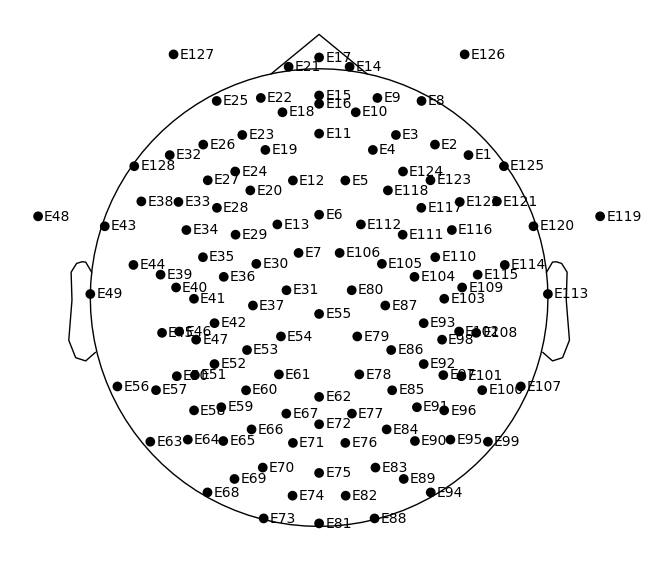

In [34]:
# Plot HydroCel 128 layout
fig = montage.plot(kind='topomap', show_names=True)
plt.show()

4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 90 unique labels.


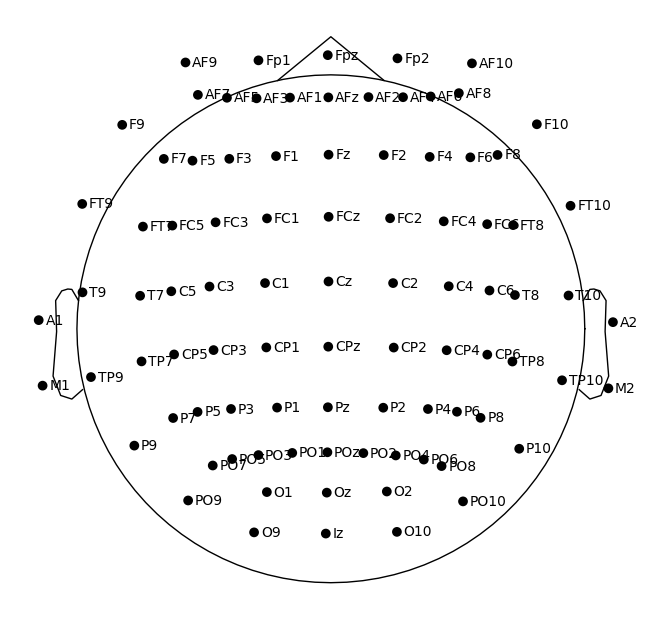

In [35]:
# Plot HydroCel 128 layout
fig = montage_1020.plot(kind='topomap', show_names=True)
plt.show()

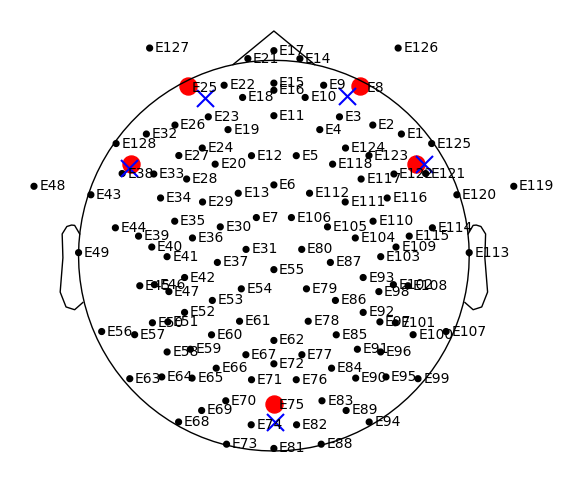

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot HydroCel 128 layout
montage.plot(kind='topomap', show_names=True, axes=ax, show=False)

# Highlight selected HydroCel electrodes (closest to 10-20 positions)
for label, electrode in closest_electrodes.items():
    pos = ch_pos_dict[electrode]
    ax.scatter(pos[0], pos[1], color='red', s=150, label=f"{label} ({electrode})")

# Highlight 10-20 system positions on the plot
for label, coord in target_positions.items():
    ax.scatter(coord[0], coord[1], color='blue', s=150, marker='x', label=f"{label} (10-20)")

plt.show()

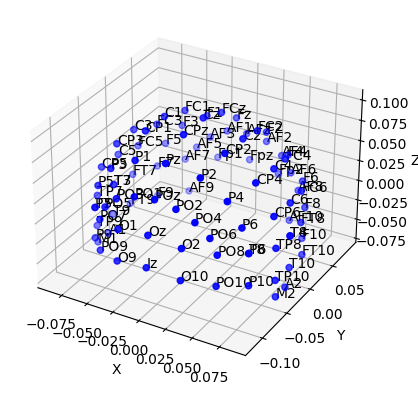

In [37]:
import mne
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create an EEG montage using the 10-20 system
montage = mne.channels.make_standard_montage('standard_1020')

# Get the electrode positions in 3D
xyz_positions = montage.get_positions()['ch_pos']

# Extract x, y, z coordinates and channel names
x = [pos[0] for pos in xyz_positions.values()]
y = [pos[1] for pos in xyz_positions.values()]
z = [pos[2] for pos in xyz_positions.values()]
labels = list(xyz_positions.keys())

# Plot the 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, color='b', marker='o')

# Annotate the points with electrode names
for i, label in enumerate(labels):
    ax.text(x[i], y[i], z[i], label, size=10, zorder=1)

# Label the axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot
plt.show()
